# 02 — Feature Engineering
**Goal:** Load the engineered features CSV, validate the features make sense,
and visualize whether features actually separate drivers.

By the end of this notebook you should see that at least some features
have clearly different distributions per driver — that's your signal that
the classifier will work.

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

RACE_TAG = f"{config['session']['year']}_{config['session']['race'].lower()}"
FEATURES_PATH = os.path.join('..', config['data']['features_dir'], f'{RACE_TAG}_features.csv')
DRIVERS = config['drivers']
COLORS = {'VER': '#1E3A8A', 'HAM': '#7C3AED', 'ALO': '#B91C1C'}

FEATURE_COLS = [
    'brake_duration_ratio',
    'throttle_smoothness',
    'full_throttle_ratio',
    'coasting_ratio',
    'gear_change_freq',
    'speed_at_throttle_lift',
    'mean_corner_speed',
    'speed_variance',
    'throttle_brake_overlap',
]

df = pd.read_csv(FEATURES_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (159, 12)


,Driver,LapNumber,LapTime_s,brake_duration_ratio,throttle_smoothness,full_throttle_ratio,coasting_ratio,gear_change_freq,speed_at_throttle_lift,mean_corner_speed,speed_variance,throttle_brake_overlap
0,ALO,2.0,99.792,0.189404,2.249337,0.466225,0.055629,7.814570,266.437500,127.299279,65.835210,0.000000
1,ALO,3.0,99.100,0.201333,2.347130,0.452000,0.056000,7.200000,283.000000,124.624802,67.424669,0.005333
2,ALO,4.0,99.548,0.218065,2.237726,0.441290,0.069677,6.838710,257.441666,129.954657,66.683179,0.021935
3,ALO,5.0,99.662,0.198932,2.310160,0.447263,0.066756,7.076101,268.326191,123.601874,66.709400,0.000000
4,ALO,6.0,99.674,0.211669,2.383152,0.461330,0.039349,6.648575,269.000000,122.752469,66.878375,0.001357


## 1. Sanity check — any nulls?

In [2]:
print('Null counts:')
print(df[FEATURE_COLS].isnull().sum())
print(f'\nTotal laps per driver:')
print(df.groupby('Driver')['LapNumber'].count())

Null counts:
brake_duration_ratio       0
throttle_smoothness        0
full_throttle_ratio        0
coasting_ratio             0
gear_change_freq           0
speed_at_throttle_lift    30
mean_corner_speed          0
speed_variance             0
throttle_brake_overlap     0
dtype: int64

Total laps per driver:
Driver
ALO    53
HAM    53
VER    53
Name: LapNumber, dtype: int64


## 2. Feature means by driver — the most important table

If features are working, you should see meaningful differences between rows.
Example: VER should have lower `throttle_smoothness` (more aggressive = higher diff between samples)
and higher `speed_at_throttle_lift` (brakes later = higher speed at lift point).

In [3]:
means = df.groupby('Driver')[FEATURE_COLS].mean().round(4)

# Normalize each column 0-1 so we can compare across different scales
means_norm = (means - means.min()) / (means.max() - means.min() + 1e-8)

print('Raw means:')
display(means)
print('\nNormalized (0=lowest, 1=highest among drivers):')
display(means_norm.round(3))

Raw means:


,brake_duration_ratio,throttle_smoothness,full_throttle_ratio,coasting_ratio,gear_change_freq,speed_at_throttle_lift,mean_corner_speed,speed_variance,throttle_brake_overlap
Driver,,,,,,,,,
ALO,0.1997,2.3423,0.4767,0.0478,7.0774,259.9385,122.5782,68.8155,0.0053
HAM,0.2200,2.3315,0.4438,0.0469,6.1620,266.8262,122.9222,69.5660,0.0099
VER,0.2001,2.3904,0.4432,0.0812,5.2729,264.6679,131.8627,65.7685,0.0006



Normalized (0=lowest, 1=highest among drivers):


,brake_duration_ratio,throttle_smoothness,full_throttle_ratio,coasting_ratio,gear_change_freq,speed_at_throttle_lift,mean_corner_speed,speed_variance,throttle_brake_overlap
Driver,,,,,,,,,
ALO,0.00,0.183,1.000,0.026,1.000,0.000,0.000,0.802,0.505
HAM,1.00,0.000,0.018,0.000,0.493,1.000,0.037,1.000,1.000
VER,0.02,1.000,0.000,1.000,0.000,0.687,1.000,0.000,0.000


## 3. Box plots — per-feature distribution per driver

For each feature, a box plot shows the spread across all laps.
Features where boxes DON'T overlap between drivers are your strongest signals.

/var/folders/05/047xdfg15wv160gg51zg14340000gn/T/ipykernel_34912/2296167098.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_driver, labels=DRIVERS, patch_artist=True, notch=False)
/var/folders/05/047xdfg15wv160gg51zg14340000gn/T/ipykernel_34912/2296167098.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_driver, labels=DRIVERS, patch_artist=True, notch=False)
/var/folders/05/047xdfg15wv160gg51zg14340000gn/T/ipykernel_34912/2296167098.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_driver, labels=DRIVERS, patch_artist=True, notch=Fa

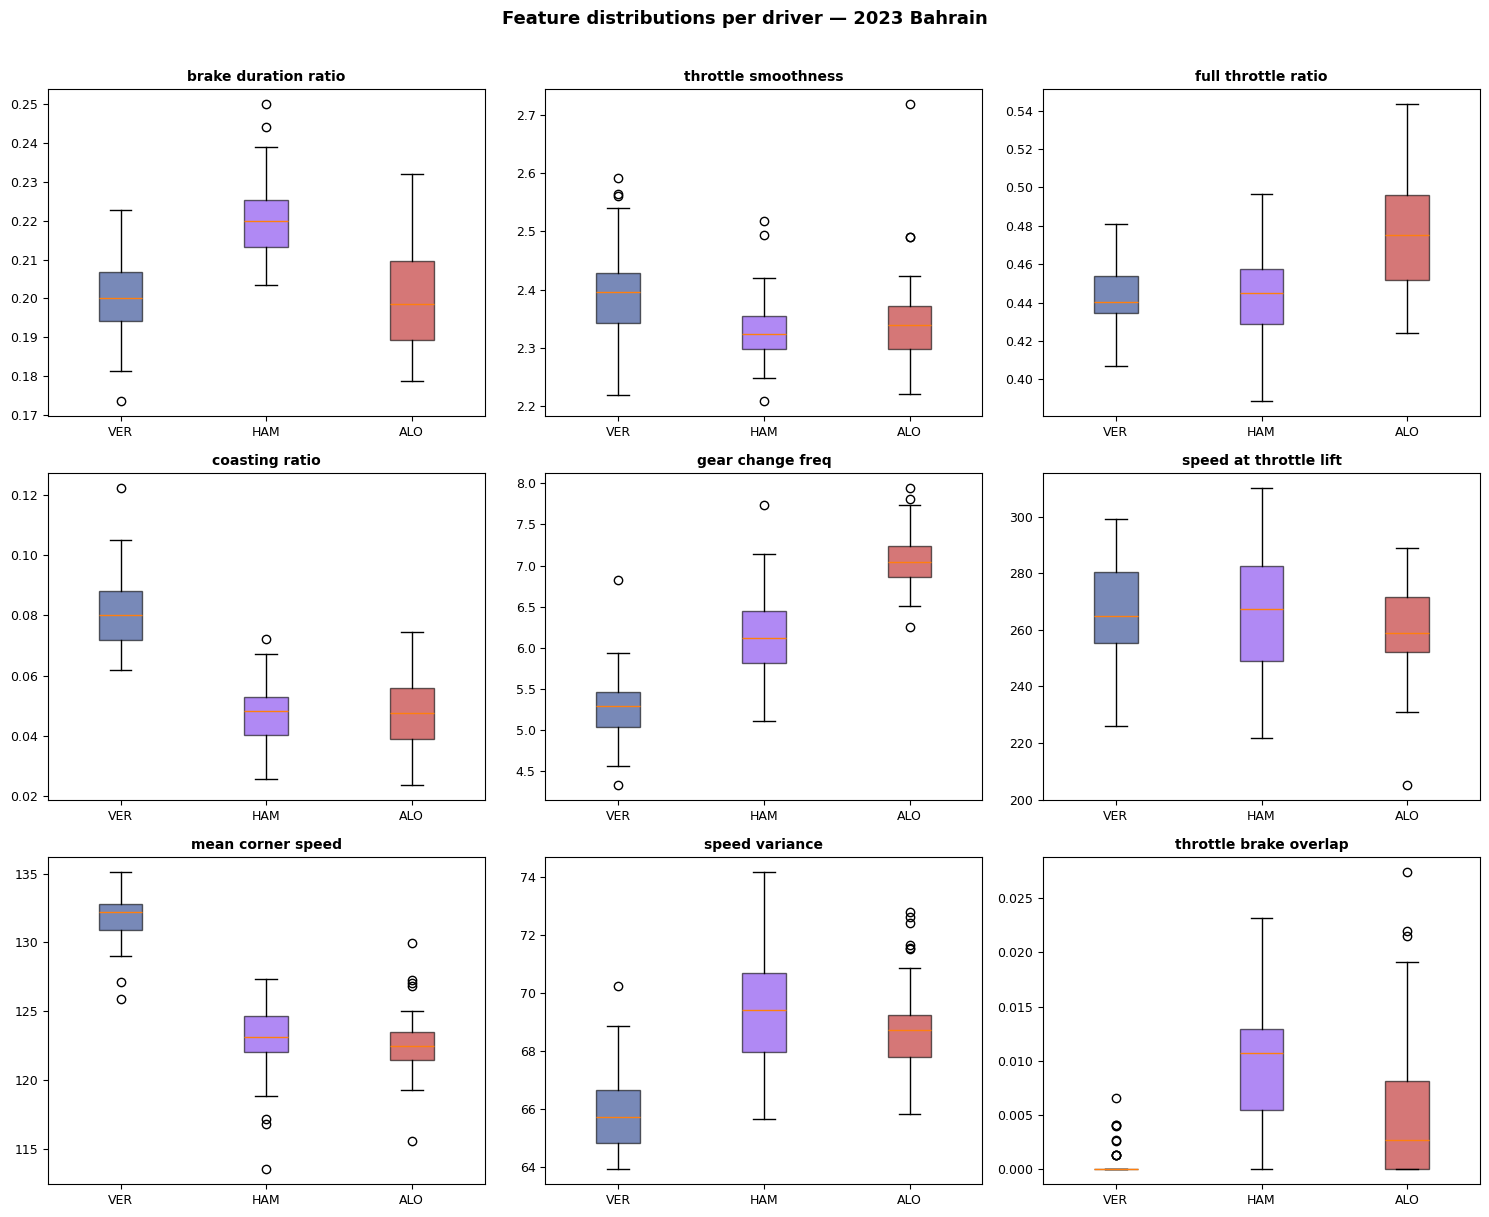

Saved to outputs/figures/02_feature_boxplots.png


In [4]:
n_features = len(FEATURE_COLS)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    data_per_driver = [df[df['Driver'] == d][feat].dropna().values for d in DRIVERS]
    bp = ax.boxplot(data_per_driver, labels=DRIVERS, patch_artist=True, notch=False)

    for patch, driver in zip(bp['boxes'], DRIVERS):
        patch.set_facecolor(COLORS[driver])
        patch.set_alpha(0.6)

    ax.set_title(feat.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions per driver — 2023 Bahrain', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/02_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/figures/02_feature_boxplots.png')

## 4. Radar chart — driver style profiles

This is the "hero" visualization for Milestone 2.
A radar chart shows each driver's normalized feature profile — their driving fingerprint shape.
If the shapes differ, the model has something to learn.

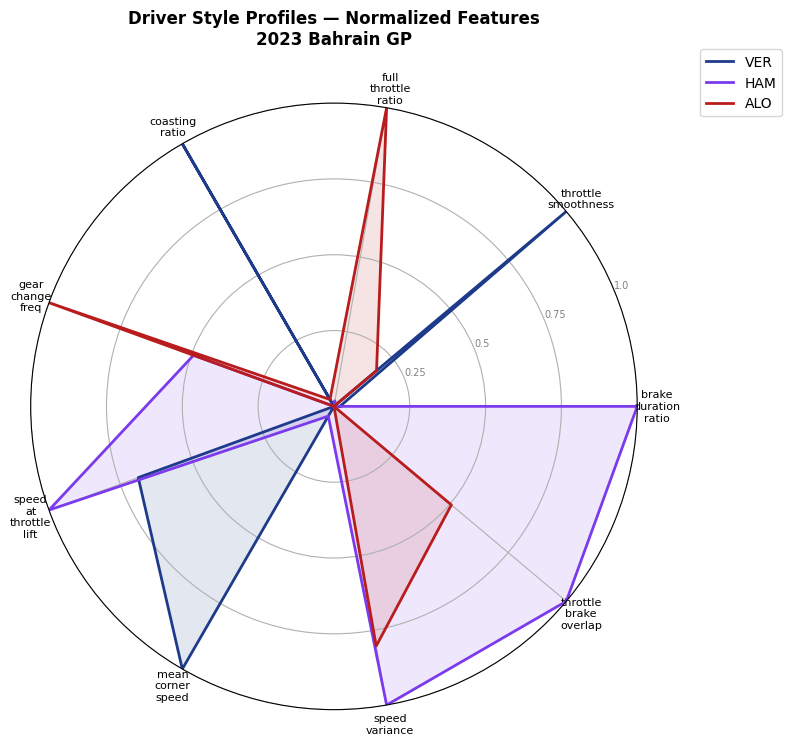

Saved: outputs/figures/02_driver_radar.png


In [5]:
from matplotlib.patches import FancyArrowPatch

# Use normalized means
labels = [f.replace('_', '\n') for f in FEATURE_COLS]
N = len(FEATURE_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for driver in DRIVERS:
    values = means_norm.loc[driver].tolist()
    values += values[:1]  # close
    ax.plot(angles, values, color=COLORS[driver], linewidth=2, label=driver)
    ax.fill(angles, values, color=COLORS[driver], alpha=0.12)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7, color='grey')
ax.set_title('Driver Style Profiles — Normalized Features\n2023 Bahrain GP', 
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.savefig('../outputs/figures/02_driver_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/02_driver_radar.png')

## 5. Correlation heatmap — are any features redundant?

Highly correlated features (|r| > 0.9) are redundant — they tell the model the same thing.
If you see that, you can drop one from each pair before training.

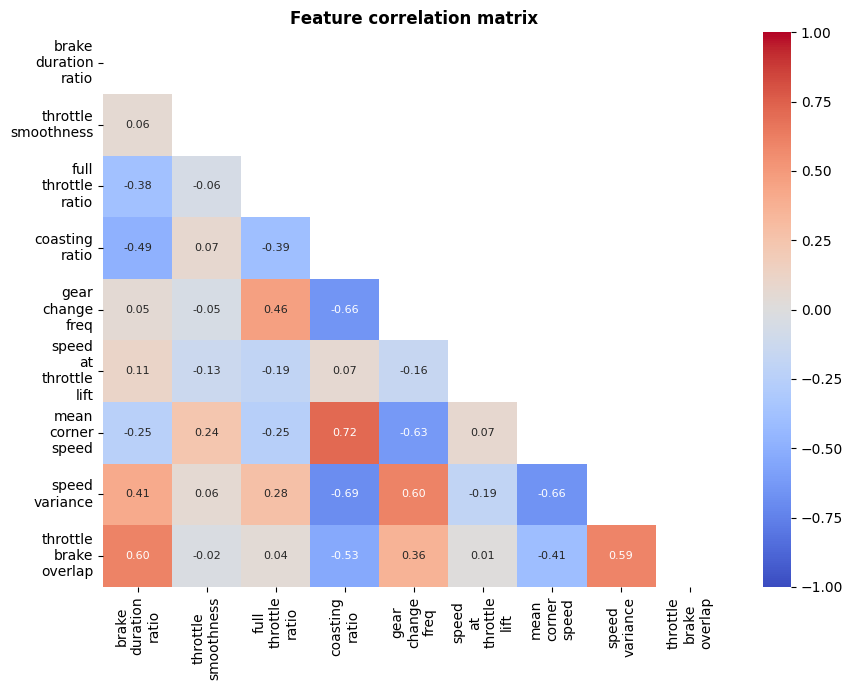

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax,
    xticklabels=[f.replace('_', '\n') for f in FEATURE_COLS],
    yticklabels=[f.replace('_', '\n') for f in FEATURE_COLS],
    annot_kws={'size': 8}
)
ax.set_title('Feature correlation matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Lap-by-lap evolution — do features drift over the race?

Drivers change behavior as tires degrade. This plot shows how
two key features evolve across the race — a tire wear signal.

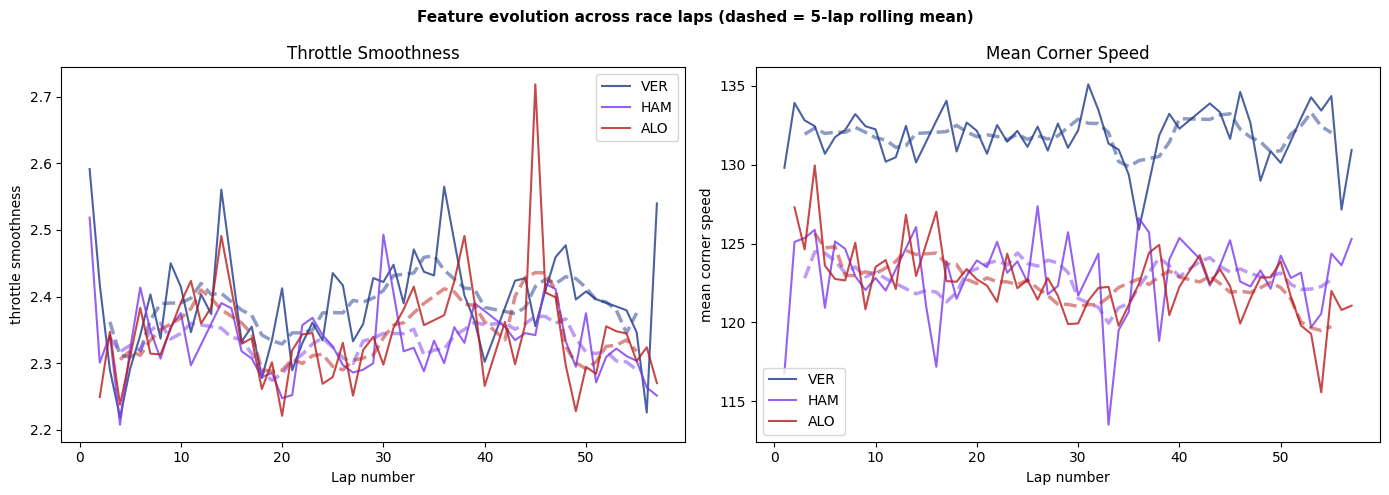

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['throttle_smoothness', 'mean_corner_speed']):
    for driver in DRIVERS:
        sub = df[df['Driver'] == driver].sort_values('LapNumber')
        ax.plot(sub['LapNumber'], sub[feat], color=COLORS[driver], 
                label=driver, alpha=0.8, linewidth=1.5)
        # Rolling mean to show trend
        rolling = sub[feat].rolling(5, center=True).mean()
        ax.plot(sub['LapNumber'], rolling, color=COLORS[driver],
                linewidth=2.5, linestyle='--', alpha=0.5)

    ax.set_xlabel('Lap number')
    ax.set_ylabel(feat.replace('_', ' '))
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend()

fig.suptitle('Feature evolution across race laps (dashed = 5-lap rolling mean)', 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/02_feature_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Milestone 2 complete ✓

You now have:
- A feature engineering pipeline in `src/features/engineer.py`
- A features CSV at `data/features/2023_bahrain_features.csv`
- Visual confirmation that features separate drivers (radar + box plots)
- Correlation analysis to check for redundant features

**Next:** `03_baseline_classifier.ipynb` — XGBoost classifier, SHAP importance, confusion matrix.